In [25]:
# --- Repro (safe, minimal) ---
import os, random, numpy as np, torch
SEED = 12345
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.set_num_threads(1)


In [26]:
# --- Path plumbing (point to src) + autoreload ---
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import ROOT as ROOT_CFG, PROCESSED_DIR, CLEANED
print("CWD:", NB)
print("SRC:", SRC)
print("ROOT:", ROOT_CFG)
print("PROC:", PROCESSED_DIR)
print("CLEANED:", CLEANED)


# --- 0) Imports & paths ---
from pathlib import Path
import numpy as np

from simulator.env import HedgingEnv
from simulator.rewards import pnl_only
from rl_agent.policy_nn import PolicyNetwork, PolicyConfig
from rl_agent.trainer import train_reinforce, TrainConfig, evaluate_env
from simulator.baselines import volatility_targeting, momentum_policy, delta_hedge_policy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CWD: /Users/ya/Desktop/deep-hedging-rl/notebooks
SRC: /Users/ya/Desktop/deep-hedging-rl/src
ROOT: /Users/ya/Desktop/deep-hedging-rl
PROC: /Users/ya/Desktop/deep-hedging-rl/data/processed
CLEANED: /Users/ya/Desktop/deep-hedging-rl/data/processed/cleaned


In [27]:
# --- 1) Load panel exported from 02_simulator ---
panel = pd.read_csv(CLEANED / "hedging_panel_spx.csv", parse_dates=["date"])
panel = panel.sort_values("date").reset_index(drop=True)

print("Panel window:", panel["date"].min(), "→", panel["date"].max())
print("Columns:", list(panel.columns)[:12], "...")

Panel window: 2005-01-21 00:00:00 → 2023-08-31 00:00:00
Columns: ['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d', 'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d', 'hvol_182d'] ...


In [28]:
# Assume `panel` already loaded and has 'date', 'ret_fwd', and your feature columns
panel = panel.sort_values("date").set_index("date")

state_cols = [
    c for c in [
        "iv_atm_30d_spx","iv_ts_slope_spx","iv_skew_30d_spx",
        "vix","rate_10y","rv_21d","hvol_30d","hvol_91d",
        "ret_1d","close_spy_z60"
    ] if c in panel.columns
]
print("STATE_COLS initial:", state_cols)

# 3) Time splits
CUT_TRAIN = "2016-12-31"
CUT_VAL   = "2019-12-31"
train = panel.loc[:CUT_TRAIN].copy()
val   = panel.loc[CUT_TRAIN:].loc[:CUT_VAL].copy()
test  = panel.loc[CUT_VAL:].copy()

if not state_cols:
    raise ValueError("state_cols is empty; please select at least one feature")

std_train = train[state_cols].std(ddof=1)
zero_sd = std_train[std_train <= 1e-8].index.tolist()
if zero_sd:
    print("Dropping near-constant features:", zero_sd)
    state_cols = [c for c in state_cols if c not in zero_sd]
    if not state_cols:
        raise ValueError("All candidate features were near-constant on the train split")
    std_train = train[state_cols].std(ddof=1)

print("STATE_COLS final:", state_cols)
mu = train[state_cols].mean()
sd = std_train.replace(0.0, 1.0).fillna(1.0)


def apply_standardize(df):
    df = df.copy()
    df[state_cols] = (df[state_cols] - mu) / sd
    return df

train_s = apply_standardize(train).dropna(subset=state_cols + ["ret_fwd"])
val_s   = apply_standardize(val).dropna(subset=state_cols + ["ret_fwd"])
test_s  = apply_standardize(test).dropna(subset=state_cols + ["ret_fwd"])

for name, df_ in [("TRAIN*", train_s), ("VAL*", val_s), ("TEST*", test_s)]:
    print(name, df_.index.min().date(), "→", df_.index.max().date(), "| n=", len(df_))


STATE_COLS initial: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']
STATE_COLS final: ['iv_atm_30d_spx', 'iv_ts_slope_spx', 'iv_skew_30d_spx', 'vix', 'rate_10y', 'rv_21d', 'hvol_30d', 'hvol_91d']
TRAIN* 2005-03-09 → 2016-12-28 | n= 6461
VAL* 2017-01-04 → 2019-12-31 | n= 3273
TEST* 2019-12-31 → 2023-08-31 | n= 7695


In [ ]:
from simulator.rewards import reward_bps

SEED = 12345

ENV_KW = dict(
    features=state_cols,        # <- name must be 'features'
    reward_fn=reward_bps,       # <- pass your reward function here
    window=30,
    txn_cost_bps=10.0,
    pos_limit=2.0,
    rebalance_every=5,          # trade once every 5 timesteps
    slippage_bps=5.0,           # 5 bps slippage per unit |Δposition|
    scaler=None,                # optional: leave None unless you have a callable
    rng_seed=SEED,              # <- name must be 'rng_seed'
    hold_on_nan=True
)

env_tr = HedgingEnv(df=train_s, **ENV_KW)
env_va = HedgingEnv(df=val_s,   **ENV_KW)
env_te = HedgingEnv(df=test_s,  **ENV_KW)


In [ ]:
# Infer obs_dim directly from the env's first observation
from simulator.baselines import volatility_targeting, momentum_policy, delta_hedge_policy

obs0 = env_tr.reset()
import numpy as np
obs_dim = int(np.asarray(obs0).reshape(-1).shape[0])
print("obs_dim =", obs_dim)

policy = PolicyNetwork(
    PolicyConfig(
        input_dim=obs_dim,   # <-- IMPORTANT
        hidden=128,
        init_log_std=-0.3,
        device="cpu",
    )
)

train_cfg = TrainConfig(
    gamma=0.99,
    entropy_coef=1e-3,   # reduced entropy bonus once exploration starts
    lr=1e-3,
    max_steps=None,      # consume full episodes for better signal
    max_rollout_steps=500,  # optional cap for quicker experiments
    device="cpu",
    print_every=25,
    normalize_returns=True,
    max_episodes=150,
)


In [ ]:
result = train_reinforce(
    env=env_tr,
    policy=policy,
    cfg=train_cfg,
)

# Normalize return types
if isinstance(result, tuple):
    # (policy, logs) or similar
    if len(result) == 2:
        trained_policy, logs = result
    else:
        trained_policy, logs = result[0], {}
elif isinstance(result, dict):
    # trainer returned only logs; policy was updated in-place
    trained_policy, logs = policy, result
else:
    # trainer returned only the trained policy
    trained_policy, logs = result, {}

history = logs if isinstance(logs, dict) else {}


In [ ]:
# Diagnostics: summarize training history
import pandas as pd

if history:
    episodes = history.get("episode_return", [])
    lengths = history.get("episode_len", [])
    df_hist = pd.DataFrame({
        "episode": np.arange(1, len(episodes) + 1),
        "episode_return": episodes,
        "episode_len": lengths,
    })
    display(df_hist.tail())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_hist["episode"], df_hist["episode_return"], lw=1.0)
    axes[0].set_title("Episode return")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Return (bp)")

    axes[1].plot(df_hist["episode"], df_hist["episode_len"], lw=1.0, color="tab:orange")
    axes[1].set_title("Episode length")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Steps")

    eval_sharpes = history.get("eval_sharpe", [])
    if eval_sharpes:
        eval_eps = np.arange(train_cfg.print_every, train_cfg.print_every * len(eval_sharpes) + 1, train_cfg.print_every)
        fig2, ax2 = plt.subplots(figsize=(6, 4))
        ax2.plot(eval_eps, eval_sharpes, marker="o")
        ax2.set_title("Eval Sharpe (deterministic)")
        ax2.set_xlabel("Episode")
        ax2.set_ylabel("Sharpe")
        ax2.axhline(0.0, color="grey", lw=0.8, ls="--")
else:
    print("No training history available (logs empty).")


In [ ]:
trained_policy.eval()
m_tr = evaluate_env(env_tr, trained_policy)
m_va = evaluate_env(env_va, trained_policy)
m_te = evaluate_env(env_te, trained_policy)

print(f"Policy Sharpe T/V/E: {m_tr['sharpe']:.3f} / {m_va['sharpe']:.3f} / {m_te['sharpe']:.3f}")

In [ ]:
#Stop the code here
# --- IGNORE ---
#import sys
#sys.exit(0)
# --- IGNORE ---


# Gae Training for all 

### Actor–Critic (GAE) script run

We replace REINFORCE with a lower-variance Actor–Critic (policy + value head, GAE),
entropy/LR schedules, grad clipping, and checkpoint on best VALID Sharpe.


In [29]:
# --- GAE imports (use your scripts) ---
from rl_agent.train_ac_gae import train as train_gae
from rl_agent.experiment import build_envs, deterministic_rewards
from rl_agent.trainer import evaluate_env

from pathlib import Path
import numpy as np
import json


In [30]:
panel = panel.copy()
panel = panel.reset_index()

In [ ]:
# --- Parameter sweep: cadence vs slippage (realistic trading assumptions) ---
from itertools import product
import json
import time
import pandas as pd

# Define grid of realistic trading knobs
SWEEP_GRID = {
    "rebalance_every": [10, 12, 15],
    "slippage_bps": [5.0, 8.0, 10.0],
    "pos_limit": [2.0],
}

# Base hyperparameters (aligned with recent run)
BASE_TRAIN_KW = dict(
    train_end="2017-12-31",
    valid_end="2019-12-31",
    window=45,
    txn_cost_bps=10.0,
    hidden=256,
    lr=1e-4,
    steps=5000,
    entropy_start=0.01,
    entropy_floor=0.001,
    device="cpu",
    seed=42,
    weight_decay=1e-4,
    early_stop_patience=400,
    max_rollout_steps=450,
)

FORCE_RETRAIN = False  # set True to rerun even if results.json already exists
RESULTS_ROOT = ROOT / "models" / "sweep_run"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

records = []
grid = list(product(
    SWEEP_GRID["rebalance_every"],
    SWEEP_GRID["slippage_bps"],
    SWEEP_GRID["pos_limit"],
))
print(f"Total combinations: {len(grid)}")
start_all = time.time()
for idx, (rebalance_every, slippage_bps, pos_limit) in enumerate(grid, 1):
    tag = f"cad{rebalance_every}_slip{slippage_bps}_pos{pos_limit}".replace('.', 'p')
    outdir = RESULTS_ROOT / tag
    outdir.mkdir(parents=True, exist_ok=True)
    ckpt_path = outdir / "best.pt"
    config_path = outdir / "config.json"
    results_path = outdir / "results.json"

    print(f"\n[{idx}/{len(grid)}] {tag}")
    if results_path.exists() and not FORCE_RETRAIN:
        metrics = json.loads(results_path.read_text())
        tr_metrics = metrics["train"]
        va_metrics = metrics["valid"]
        te_metrics = metrics["test"]
    else:
        result = train_gae(
            panel=panel,
            state_cols=state_cols,
            pos_limit=pos_limit,
            rebalance_every=rebalance_every,
            slippage_bps=slippage_bps,
            save_ckpt=str(ckpt_path),
            save_config=str(config_path),
            save_outdir=str(outdir),
            track_history=False,
            return_history=False,
            **BASE_TRAIN_KW,
        )
        if isinstance(result, tuple) and len(result) == 3:
            policy, metrics_tuple, _ = result
        else:
            policy, metrics_tuple = result
        tr_metrics, va_metrics, te_metrics = metrics_tuple
        metrics = {"train": tr_metrics, "valid": va_metrics, "test": te_metrics}
        results_path.write_text(json.dumps(metrics, indent=2))

    records.append({
        "tag": tag,
        "rebalance_every": rebalance_every,
        "slippage_bps": slippage_bps,
        "pos_limit": pos_limit,
        "train_sharpe": tr_metrics["sharpe"],
        "valid_sharpe": va_metrics["sharpe"],
        "test_sharpe": te_metrics["sharpe"],
        "valid_mean": va_metrics["mean"],
        "test_mean": te_metrics["mean"],
        "valid_std": va_metrics["std"],
        "test_std": te_metrics["std"],
    })

elapsed = time.time() - start_all
print(f"\nSweep completed in {elapsed/60:.1f} minutes")

sweep_df = pd.DataFrame(records).sort_values(by=['test_sharpe', 'valid_sharpe'], ascending=False).reset_index(drop=True)
display(sweep_df)
print("Best configuration candidate:")
print(sweep_df.iloc[0])



Total combinations: 9

[1/9] cad10_slip5p0_pos2p0
Env(train) ready. input_dim=360 (window=45, n_features=8)
[00050] Train Sharpe 0.124 | Valid Sharpe 0.729 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe 0.020 | Valid Sharpe 0.562 | LR 9.99e-05 | Ent 0.009
[00150] Train Sharpe 0.221 | Valid Sharpe 0.598 | LR 9.98e-05 | Ent 0.009
[00200] Train Sharpe 0.031 | Valid Sharpe -0.185 | LR 9.96e-05 | Ent 0.009
[00250] Train Sharpe 0.077 | Valid Sharpe -0.009 | LR 9.94e-05 | Ent 0.009
[00300] Train Sharpe 0.149 | Valid Sharpe 0.323 | LR 9.91e-05 | Ent 0.008
[00350] Train Sharpe 0.163 | Valid Sharpe 0.357 | LR 9.88e-05 | Ent 0.008
[00400] Train Sharpe 0.196 | Valid Sharpe 0.535 | LR 9.84e-05 | Ent 0.008
[00450] Train Sharpe 0.215 | Valid Sharpe 0.609 | LR 9.80e-05 | Ent 0.008
Early stopping at step 450 (no valid improvement for 400 steps).
Loaded best checkpoint (valid Sharpe=0.729).
FINAL: {
  "train": {
    "mean": 0.12291497314443274,
    "std": 15.70280765791985,
    "sharpe": 0.1242589701526

,tag,rebalance_every,slippage_bps,pos_limit,train_sharpe,valid_sharpe,test_sharpe,valid_mean,test_mean,valid_std,test_std
0,cad15_slip5p0_pos2p0,15,5.0,2.0,0.303388,0.524632,0.352532,0.151149,0.150592,4.573513,6.781131
1,cad15_slip8p0_pos2p0,15,8.0,2.0,0.260503,0.588443,0.315613,0.177213,0.163086,4.780711,8.202777
2,cad15_slip10p0_pos2p0,15,10.0,2.0,0.211550,0.614755,0.275311,0.195892,0.167556,5.058415,9.661325
3,cad10_slip5p0_pos2p0,10,5.0,2.0,0.124259,0.728525,0.206461,0.264560,0.181208,5.764747,13.932834
4,cad10_slip10p0_pos2p0,10,10.0,2.0,0.104146,0.693464,0.180799,0.303379,0.199726,6.944846,17.536322
5,cad10_slip8p0_pos2p0,10,8.0,2.0,0.131459,0.809891,0.093332,0.189333,0.025387,3.711085,4.317975
6,cad12_slip10p0_pos2p0,12,10.0,2.0,0.273744,0.867894,0.079749,0.546129,0.059738,9.989153,11.891178
7,cad12_slip5p0_pos2p0,12,5.0,2.0,0.300637,0.732823,0.031140,0.393520,0.025460,8.524479,12.978620
8,cad12_slip8p0_pos2p0,12,8.0,2.0,0.329597,0.889111,0.010773,0.405775,0.006159,7.244849,9.075291


Best configuration candidate:
tag                cad15_slip5p0_pos2p0
rebalance_every                      15
slippage_bps                        5.0
pos_limit                           2.0
train_sharpe                   0.303388
valid_sharpe                   0.524632
test_sharpe                    0.352532
valid_mean                     0.151149
test_mean                      0.150592
valid_std                      4.573513
test_std                       6.781131
Name: 0, dtype: object


In [32]:
# --- Train final GAE run using best sweep configuration ---
best_row = sweep_df.iloc[0]
print("Using best sweep params:", best_row.to_dict())

RUN_DIR = ROOT / "models" / f"gae_{best_row['tag']}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CFG = dict(
    panel=panel,
    state_cols=state_cols,
    train_end=BASE_TRAIN_KW["train_end"],
    valid_end=BASE_TRAIN_KW["valid_end"],
    window=BASE_TRAIN_KW["window"],
    txn_cost_bps=BASE_TRAIN_KW["txn_cost_bps"],
    pos_limit=float(best_row["pos_limit"]),
    rebalance_every=int(best_row["rebalance_every"]),
    slippage_bps=float(best_row["slippage_bps"]),
    hidden=BASE_TRAIN_KW["hidden"],
    lr=BASE_TRAIN_KW["lr"],
    steps=BASE_TRAIN_KW["steps"],
    entropy_start=BASE_TRAIN_KW["entropy_start"],
    entropy_floor=BASE_TRAIN_KW["entropy_floor"],
    device=BASE_TRAIN_KW["device"],
    seed=BASE_TRAIN_KW["seed"],
    weight_decay=BASE_TRAIN_KW["weight_decay"],
    early_stop_patience=BASE_TRAIN_KW["early_stop_patience"],
    max_rollout_steps=BASE_TRAIN_KW["max_rollout_steps"],
    save_ckpt=str(RUN_DIR / "best.pt"),
    save_config=str(RUN_DIR / "config.json"),
    save_outdir=str(RUN_DIR),
    track_history=True,
    return_history=True,
)

policy_ac, (tr_ac, va_ac, te_ac), history_ac = train_gae(**FINAL_CFG)
print("GAE (TRAIN):", tr_ac)
print("GAE (VALID):", va_ac)
print("GAE (TEST) :", te_ac)

FINAL_PARAMS = {
    "train_end": FINAL_CFG["train_end"],
    "valid_end": FINAL_CFG["valid_end"],
    "window": FINAL_CFG["window"],
    "txn_cost_bps": FINAL_CFG["txn_cost_bps"],
    "pos_limit": FINAL_CFG["pos_limit"],
    "rebalance_every": FINAL_CFG["rebalance_every"],
    "slippage_bps": FINAL_CFG["slippage_bps"],
}


Using best sweep params: {'tag': 'cad15_slip5p0_pos2p0', 'rebalance_every': 15, 'slippage_bps': 5.0, 'pos_limit': 2.0, 'train_sharpe': 0.30338785983171485, 'valid_sharpe': 0.5246318629119266, 'test_sharpe': 0.3525322703206107, 'valid_mean': 0.1511486785206811, 'test_mean': 0.15059159471567665, 'valid_std': 4.573513459233868, 'test_std': 6.781130852933693}
Env(train) ready. input_dim=360 (window=45, n_features=8)
[00050] Train Sharpe 0.303 | Valid Sharpe 0.525 | LR 1.00e-04 | Ent 0.010
[00100] Train Sharpe 0.341 | Valid Sharpe 0.324 | LR 9.99e-05 | Ent 0.009
[00150] Train Sharpe 0.078 | Valid Sharpe -0.078 | LR 9.98e-05 | Ent 0.009
[00200] Train Sharpe 0.109 | Valid Sharpe -0.000 | LR 9.96e-05 | Ent 0.009
[00250] Train Sharpe 0.152 | Valid Sharpe 0.183 | LR 9.94e-05 | Ent 0.009
[00300] Train Sharpe 0.167 | Valid Sharpe 0.330 | LR 9.91e-05 | Ent 0.008
[00350] Train Sharpe 0.186 | Valid Sharpe 0.429 | LR 9.88e-05 | Ent 0.008
[00400] Train Sharpe 0.022 | Valid Sharpe 0.230 | LR 9.84e-05 | 

In [33]:
# --- Build envs exactly as the final run sees them ---
envs = build_envs(
    panel=panel,
    features=state_cols,
    train_end=FINAL_PARAMS["train_end"],
    valid_end=FINAL_PARAMS["valid_end"],
    window=FINAL_PARAMS["window"],
    txn_cost_bps=FINAL_PARAMS["txn_cost_bps"],
    pos_limit=FINAL_PARAMS["pos_limit"],
    rebalance_every=FINAL_PARAMS["rebalance_every"],
    slippage_bps=FINAL_PARAMS["slippage_bps"],
)

env_tr, env_va, env_te = envs["env_tr"], envs["env_va"], envs["env_te"]

# --- Evaluate Sharpe deterministically ---
res_tr = evaluate_env(env_tr, policy_ac, deterministic=True)
res_va = evaluate_env(env_va, policy_ac, deterministic=True)
res_te = evaluate_env(env_te, policy_ac, deterministic=True)

print("Deterministic Sharpe — TRAIN:", f"{res_tr['sharpe']:.3f}")
print("Deterministic Sharpe — VALID:", f"{res_va['sharpe']:.3f}")
print("Deterministic Sharpe — TEST :", f"{res_te['sharpe']:.3f}")


Deterministic Sharpe — TRAIN: 0.303
Deterministic Sharpe — VALID: 0.525
Deterministic Sharpe — TEST : 0.353


,step,train_sharpe,valid_sharpe
4,250,0.152165,0.183352
5,300,0.166818,0.330259
6,350,0.186016,0.429234
7,400,0.022445,0.229571
8,450,-0.173102,-0.222048


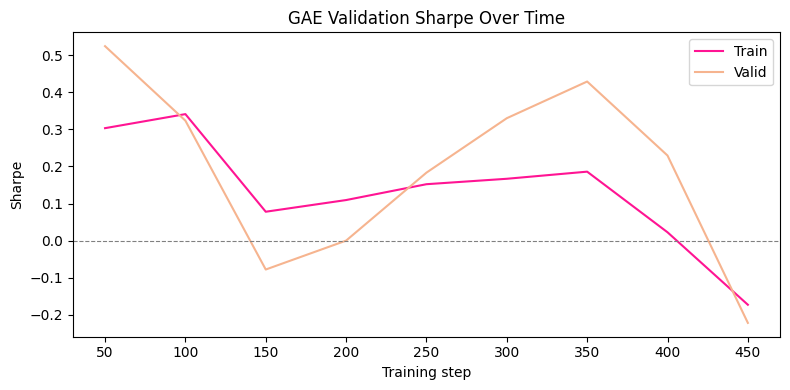

In [34]:
# Plot validation Sharpe trajectory
if history_ac and history_ac.get("eval_step"):
    hist_df = pd.DataFrame({
        "step": history_ac["eval_step"],
        "train_sharpe": history_ac.get("train_sharpe", []),
        "valid_sharpe": history_ac.get("valid_sharpe", []),
    })
    display(hist_df.tail())

    plt.figure(figsize=(8, 4))
    plt.plot(hist_df["step"], hist_df["train_sharpe"], label="Train", color='deeppink')
    plt.plot(hist_df["step"], hist_df["valid_sharpe"], label="Valid")
    plt.title("GAE Validation Sharpe Over Time")
    plt.xlabel("Training step")
    plt.ylabel("Sharpe")
    plt.axhline(0.0, color="grey", lw=0.8, ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation history recorded.")


In [35]:
# Compare GAE policy against baselines (deterministic evaluation)
from collections import OrderedDict

def _wrap_callable(fn):
    class _Tmp:
        def act(self, obs, deterministic=True):
            return float(fn(obs)), None, None
    return _Tmp()

comparisons = OrderedDict()
# if momentum_policy() and delta_hedge_policy(...) return plain callables,
# wrap them so they expose .act as evaluate_env expects.
#comparisons["momentum"] = _wrap_callable(momentum_policy())
comparisons["delta_hedge"] = _wrap_callable(delta_hedge_policy(lambda obs: obs[-1, 0]))
comparisons["spy_hold"] = _wrap_callable(lambda obs: env_tr.pos_limit)
comparisons["gae_policy"] = policy_ac
comparisons["vol_target"] = _wrap_callable(volatility_targeting(ann_vol_target=0.15))

for name, pol in list(comparisons.items()):
    if callable(pol) and not hasattr(pol, "act"):
        comparisons[name] = _wrap_callable(pol)

if 'baselines' in globals():
    for name, fn in baselines.items():
        comparisons[name] = _wrap_callable(fn)

rows = []
for name, pol in comparisons.items():
    metrics = {
        "train": evaluate_env(env_tr, pol, deterministic=True),
        "valid": evaluate_env(env_va, pol, deterministic=True),
        "test": evaluate_env(env_te, pol, deterministic=True),
    }
    for split, vals in metrics.items():
        rows.append({
            "policy": name,
            "split": split,
            "mean": vals["mean"],
            "std": vals["std"],
            "sharpe": vals["sharpe"],
            "steps": vals["steps"],
        })

results_df = pd.DataFrame(rows)
display(results_df.pivot(index="policy", columns="split", values="sharpe"))
results_df


split,test,train,valid
policy,,,
delta_hedge,-0.253790,-0.206787,-0.211900
gae_policy,0.352532,0.303388,0.524632
spy_hold,0.210481,0.386436,0.332611
vol_target,0.117936,0.210080,0.079832


,policy,split,mean,std,sharpe,steps
0,delta_hedge,train,-0.597463,45.865724,-0.206787,7808
1,delta_hedge,valid,-0.256518,19.217071,-0.211900,2459
2,delta_hedge,test,-0.627090,39.224317,-0.253790,7613
3,spy_hold,train,3.268642,134.273382,0.386436,7808
4,spy_hold,valid,1.458410,69.605435,0.332611,2459
5,spy_hold,test,1.220744,92.068575,0.210481,7613
6,gae_policy,train,0.162001,8.476566,0.303388,7808
7,gae_policy,valid,0.151149,4.573513,0.524632,2459
8,gae_policy,test,0.150592,6.781131,0.352532,7613
9,vol_target,train,0.745967,56.368250,0.210080,7808


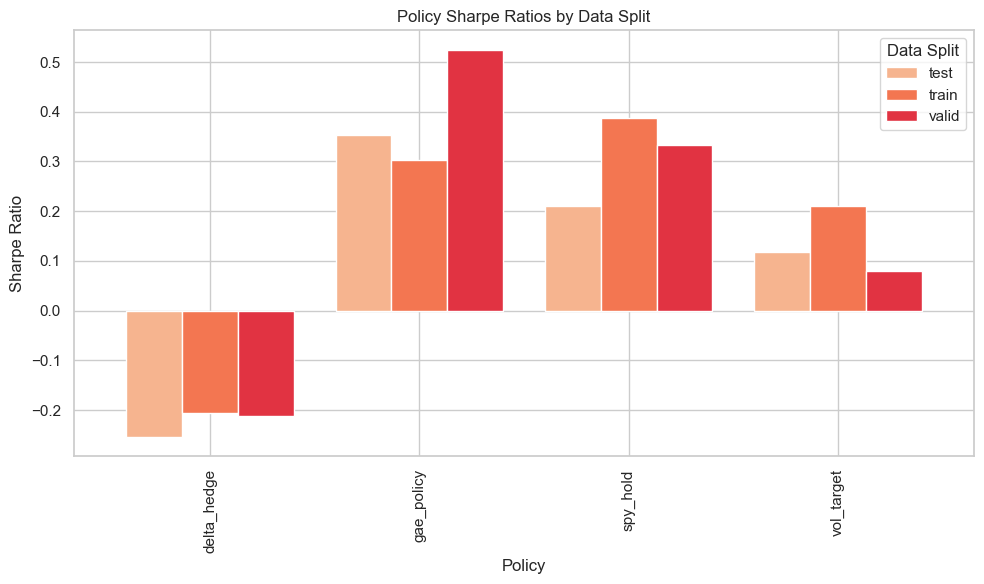

In [41]:
import seaborn as sns

pivot = results_df.pivot(index="policy", columns="split", values="sharpe")

#Plotting the pivot table
sns.set_theme(style="whitegrid")
sns.set_palette("rocket_r")
pivot.plot(kind='bar', figsize=(10,6), width=0.8)
plt.title('Policy Sharpe Ratios by Data Split')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Policy')
plt.legend(title='Data Split')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / "policy_sharpe_ratios.png", dpi=150)
plt.show()


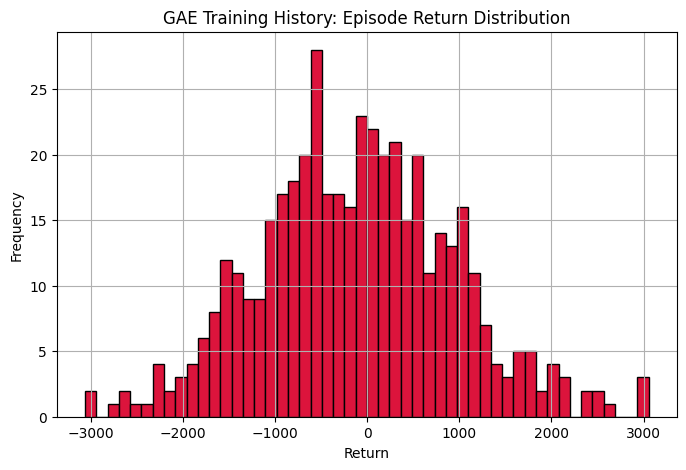

In [37]:
returns = pd.Series(history_ac['episode_return'])

returns.hist(bins=50, figsize=(8, 5), color='crimson', edgecolor='black')
plt.title("GAE Training History: Episode Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.savefig(ROOT / 'reports' / 'figures' / "gae_episode_return_distribution.png")
plt.show()

# Evaluation

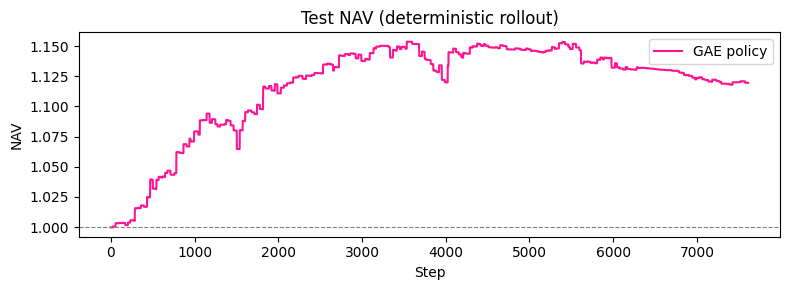

In [38]:
from rl_agent.experiment import deterministic_rewards

rewards_test = deterministic_rewards(env_te, policy_ac)
equity_curve = (1 + rewards_test / 1e4).cumprod()  # convert bp reward to NAV path

plt.figure(figsize=(8,3))
plt.plot(equity_curve, label="GAE policy", color="deeppink")
plt.axhline(1.0, color="grey", lw=0.8, ls="--")
plt.title("Test NAV (deterministic rollout)")
plt.xlabel("Step")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
rollout = env_te.rollout(lambda obs: policy_ac.act(obs, deterministic=True)[0])
pos = rollout["positions"]
turnover = np.abs(np.diff(pos)).sum()
print("Total turnover (|Δpos| sum):", turnover)


Total turnover (|Δpos| sum): 21.682841490022838
